<a href="https://colab.research.google.com/github/smitp2705/supervised-pr2/blob/main/supervised_learning_pr_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section A – One-Line Answers

Q1. What is regularization?
Answer: Regularization is a technique used to reduce overfitting by adding a penalty term to the model's loss function.

Q2. Difference between Ridge and Lasso Regression?
Answer: Ridge uses L2 regularization to shrink coefficients, while Lasso uses L1 regularization to shrink some coefficients to zero for feature selection.

Q3. What is cross-validation?
Answer: Cross-validation is a technique that evaluates a model's performance by training and testing it on different subsets of the data.

Q4. Explain K-Fold, Stratified K-Fold, LOOCV, and TimeSeriesSplit.

K-Fold: Splits the dataset into K equal folds for training and testing.
Stratified K-Fold: Maintains the same target distribution in every fold.
LOOCV: Uses one sample for testing and all remaining samples for training in each iteration.
TimeSeriesSplit: Splits data sequentially while preserving chronological order for time-series datasets.

Q5. Why don't tree-based models require feature scaling?
Answer: Tree-based models split data based on feature values rather than distances, so feature scaling is unnecessary.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [6]:
df=pd.read_csv("/content/Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [7]:
df.shape

(3800, 12)

In [ ]:
df.isnull().sum()

,0
property_id,0
sale_date,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
property_age,0
distance_city_km,0
near_school,0
near_metro,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [ ]:
# Duplicate records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# Convert sale_date into datetime

df["sale_date"] = pd.to_datetime(df["sale_date"])

In [ ]:
# Extract year and month

df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month

In [ ]:
# Drop sale_date

df.drop("sale_date", axis=1, inplace=True)

In [ ]:
# Features

X = df.drop("house_price_inr", axis=1)

# Target

y = df["house_price_inr"]

X.head()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,sale_year,sale_month
0,200001,2181,6,4,8.1,21,3.8,0,0,4.84,2014,1
1,200002,2383,5,4,5.3,28,10.9,1,1,2.89,2019,12
2,200003,1047,3,3,5.9,7,27.5,0,1,4.04,2016,10
3,200004,1753,4,3,7.0,27,12.1,0,0,3.28,2013,3
4,200005,1728,4,4,10.0,32,1.4,0,1,3.84,2013,7


In [ ]:
y.head()

,house_price_inr
0,35154898
1,26710893
2,11216242
3,21984310
4,25080429


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3040, 12)
(760, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Create scaler

scaler = StandardScaler()

# Scale training data

X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data

X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Training Features :", X_train_scaled.shape)

print("Testing Features :", X_test_scaled.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (3040, 12)
Testing Features : (760, 12)
Training Target : (3040,)
Testing Target : (760,)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
# Create Ridge model

ridge = Ridge()

# Train model

ridge.fit(X_train_scaled, y_train)

# Predictions

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

In [ ]:
# Training Metrics

ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_train_r2 = r2_score(y_train, ridge_train_pred)

# Testing Metrics

ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print("RIDGE TRAIN RESULTS")
print("MAE :", ridge_train_mae)
print("RMSE :", ridge_train_rmse)
print("R2 :", ridge_train_r2)

print()

print("RIDGE TEST RESULTS")
print("MAE :", ridge_test_mae)
print("RMSE :", ridge_test_rmse)
print("R2 :", ridge_test_r2)

RIDGE TRAIN RESULTS
MAE : 1895770.3962516135
RMSE : 2481539.557639123
R2 : 0.9174588793922067

RIDGE TEST RESULTS
MAE : 1945963.165966461
RMSE : 2540065.2752834135
R2 : 0.9198867816702514


In [ ]:
param_grid = {
    "alpha":[0.001,0.01,0.1,1,10,50,100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

ridge_grid.fit(X_train_scaled,y_train)

print("Best Alpha :", ridge_grid.best_params_)
print("Best CV Score :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best CV Score : 0.91643763214708


In [ ]:
best_ridge = ridge_grid.best_estimator_

best_ridge.fit(X_train_scaled,y_train)

ridge_pred = best_ridge.predict(X_test_scaled)

print("Best Ridge R2 :",r2_score(y_test,ridge_pred))
print("Best Ridge RMSE :",np.sqrt(mean_squared_error(y_test,ridge_pred)))

Best Ridge R2 : 0.9198867816702514
Best Ridge RMSE : 2540065.2752834135


In [ ]:
lasso = Lasso()

lasso.fit(X_train_scaled,y_train)

lasso_train_pred = lasso.predict(X_train_scaled)

lasso_test_pred = lasso.predict(X_test_scaled)

In [ ]:
lasso_train_mae = mean_absolute_error(y_train,lasso_train_pred)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train,lasso_train_pred))
lasso_train_r2 = r2_score(y_train,lasso_train_pred)

lasso_test_mae = mean_absolute_error(y_test,lasso_test_pred)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test,lasso_test_pred))
lasso_test_r2 = r2_score(y_test,lasso_test_pred)

print("LASSO TRAIN RESULTS")
print("MAE :",lasso_train_mae)
print("RMSE :",lasso_train_rmse)
print("R2 :",lasso_train_r2)

print()

print("LASSO TEST RESULTS")
print("MAE :",lasso_test_mae)
print("RMSE :",lasso_test_rmse)
print("R2 :",lasso_test_r2)

LASSO TRAIN RESULTS
MAE : 1895883.5313990135
RMSE : 2481535.7514138846
R2 : 0.9174591325978061

LASSO TEST RESULTS
MAE : 1946116.772139427
RMSE : 2539836.2933370196
R2 : 0.9199012251209642


In [ ]:
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

lasso_grid.fit(X_train_scaled,y_train)

print("Best Alpha :",lasso_grid.best_params_)
print("Best Score :",lasso_grid.best_score_)

Best Alpha : {'alpha': 100}
Best Score : 0.9164371106919751


In [ ]:
best_lasso = lasso_grid.best_estimator_

best_lasso.fit(X_train_scaled,y_train)

lasso_pred = best_lasso.predict(X_test_scaled)

print("Best Lasso R2 :",r2_score(y_test,lasso_pred))
print("Best Lasso RMSE :",np.sqrt(mean_squared_error(y_test,lasso_pred)))

Best Lasso R2 : 0.9199001325584748
Best Lasso RMSE : 2539853.6152024595


In [ ]:
comparison = pd.DataFrame({
    "Model":["Ridge","Lasso"],
    "MAE":[
        mean_absolute_error(y_test,ridge_pred),
        mean_absolute_error(y_test,lasso_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,ridge_pred)),
        np.sqrt(mean_squared_error(y_test,lasso_pred))
    ],
    "R2":[
        r2_score(y_test,ridge_pred),
        r2_score(y_test,lasso_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Ridge,1.945963e+06,2.540065e+06,0.919887
1,Lasso,1.946119e+06,2.539854e+06,0.919900


In [ ]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Ridge":best_ridge.coef_,
    "Lasso":best_lasso.coef_
})

coef

,Feature,Ridge,Lasso
0,property_id,-6.527146e+04,-6.529694e+04
1,area_sqft,6.950206e+06,6.957515e+06
2,bedrooms,2.925828e+05,2.864038e+05
3,bathrooms,2.740168e+05,2.740541e+05
4,location_score,3.681382e+06,3.683439e+06
5,property_age,-6.501791e+05,-6.502685e+05
6,distance_city_km,-2.688562e+04,-2.544449e+04
7,near_school,1.327036e+04,1.309780e+04
8,near_metro,5.281289e+04,5.280225e+04
9,crime_rate_index,-1.398465e+05,-1.396840e+05


In [ ]:
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

In [ ]:
# K-Fold Cross Validation

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_kfold = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("K-Fold Scores")
print(ridge_kfold)

print("\nAverage R² :", ridge_kfold.mean())

K-Fold Scores
[0.91949086 0.90754671 0.91440247 0.920567   0.91974665]

Average R² : 0.9163507395114581


In [ ]:
# Create target bins

y_bins = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop"
)

In [ ]:
# Stratified K-Fold

stratified = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_stratified = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=stratified.split(X_train_scaled, y_bins),
    scoring="r2"
)

print("Stratified Scores")
print(ridge_stratified)

print("\nAverage R² :", ridge_stratified.mean())

Stratified Scores
[0.9113401  0.92305599 0.91777946 0.91884865 0.91270152]

Average R² : 0.9167451440077171


In [ ]:
df_time = df.sort_values(
    by=["sale_year", "sale_month"]
).reset_index(drop=True)

In [ ]:
X_time = df_time.drop("house_price_inr", axis=1)
y_time = df_time["house_price_inr"]

In [ ]:
# Scale features

X_time_scaled = scaler.fit_transform(X_time)

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_time = cross_val_score(
    best_ridge,
    X_time_scaled,
    y_time,
    cv=tscv,
    scoring="r2"
)

print("Time Series Scores")

print(ridge_time)

print("\nAverage R² :", ridge_time.mean())

Time Series Scores
[0.91013297 0.91863839 0.92067251 0.91091268 0.9232592 ]

Average R² : 0.9167231504976987


In [ ]:
cv_results = pd.DataFrame({

    "Method":[
        "K-Fold",
        "Stratified K-Fold",
        "Time Series"
    ],

    "Average R²":[

        ridge_kfold.mean(),

        ridge_stratified.mean(),

        ridge_time.mean()
    ]

})

cv_results

,Method,Average R²
0,K-Fold,0.916351
1,Stratified K-Fold,0.916745
2,Time Series,0.916723


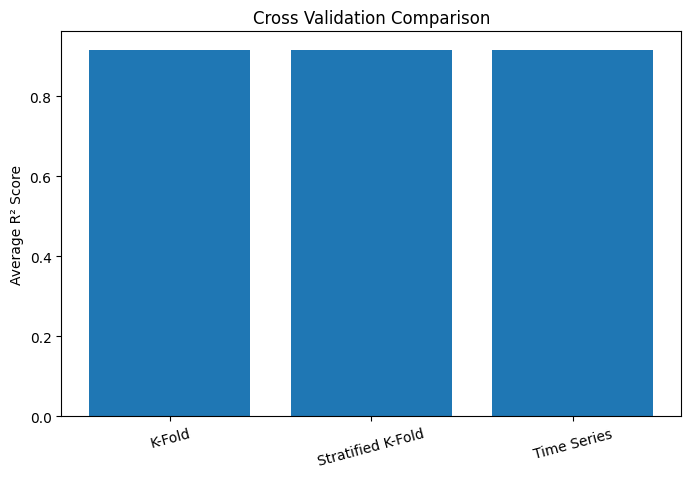

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Method"],
    cv_results["Average R²"]
)

plt.title("Cross Validation Comparison")

plt.ylabel("Average R² Score")

plt.xticks(rotation=15)

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Create Decision Tree model

dt_model = DecisionTreeRegressor(random_state=42)

# Train the model

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
dt_train_pred = dt_model.predict(X_train)

dt_test_pred = dt_model.predict(X_test)

In [ ]:
print("Decision Tree Performance")

print("Training R² :", r2_score(y_train, dt_train_pred))
print("Testing R² :", r2_score(y_test, dt_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, dt_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, dt_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, dt_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, dt_test_pred))

Decision Tree Performance
Training R² : 1.0
Testing R² : 0.8554034375200549
Training RMSE : 0.0
Testing RMSE : 3412493.0244544954
Training MAE : 0.0
Testing MAE : 2503382.3736842107


In [ ]:
param_grid = {

    "max_depth":[3,5,7,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid_dt = GridSearchCV(

    estimator=DecisionTreeRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_dt.fit(X_train, y_train)

print("Best Parameters :", grid_dt.best_params_)

print("Best CV Score :", grid_dt.best_score_)

Best Parameters : {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score : 0.8945111446109794


In [ ]:
best_dt = grid_dt.best_estimator_

best_dt.fit(X_train, y_train)

best_dt_pred = best_dt.predict(X_test)

print("Best Decision Tree R² :", r2_score(y_test, best_dt_pred))

print("Best Decision Tree RMSE :", np.sqrt(mean_squared_error(y_test, best_dt_pred)))

Best Decision Tree R² : 0.9053933909413185
Best Decision Tree RMSE : 2760282.463631185


In [ ]:
rf_model = RandomForestRegressor(

    random_state=42,

    n_estimators=100

)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_train_pred = rf_model.predict(X_train)

rf_test_pred = rf_model.predict(X_test)

In [ ]:
print("Random Forest Performance")

print("Training R² :", r2_score(y_train, rf_train_pred))
print("Testing R² :", r2_score(y_test, rf_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, rf_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, rf_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, rf_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, rf_test_pred))

Random Forest Performance
Training R² : 0.9893454995493671
Testing R² : 0.9268348205690184
Training RMSE : 891564.0908467264
Testing RMSE : 2427420.4649315784
Training MAE : 661432.5514934211
Testing MAE : 1770096.2551842106


In [ ]:
rf_param = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_rf = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=rf_param,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_rf.fit(X_train, y_train)

print("Best Parameters :", grid_rf.best_params_)

print("Best CV Score :", grid_rf.best_score_)

Best Parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score : 0.9231840310238777


In [ ]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X_train, y_train)

rf_best_pred = best_rf.predict(X_test)

print("Best Random Forest R² :", r2_score(y_test, rf_best_pred))

print("Best Random Forest RMSE :", np.sqrt(mean_squared_error(y_test, rf_best_pred)))

Best Random Forest R² : 0.9278458595507011
Best Random Forest RMSE : 2410590.3671078044


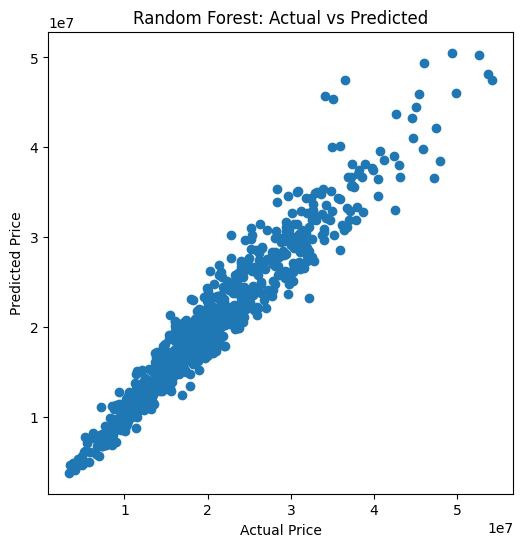

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_best_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [ ]:
tree_results = pd.DataFrame({

    "Model":["Decision Tree","Random Forest"],

    "MAE":[

        mean_absolute_error(y_test, best_dt_pred),

        mean_absolute_error(y_test, rf_best_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test, best_dt_pred)),

        np.sqrt(mean_squared_error(y_test, rf_best_pred))

    ],

    "R²":[

        r2_score(y_test, best_dt_pred),

        r2_score(y_test, rf_best_pred)

    ]

})

tree_results

,Model,MAE,RMSE,R²
0,Decision Tree,2.035498e+06,2.760282e+06,0.905393
1,Random Forest,1.761206e+06,2.410590e+06,0.927846


In [ ]:
print("Decision Tree")

print("Training R² :", r2_score(y_train, best_dt.predict(X_train)))

print("Testing R² :", r2_score(y_test, best_dt.predict(X_test)))

print("\nRandom Forest")

print("Training R² :", r2_score(y_train, best_rf.predict(X_train)))

print("Testing R² :", r2_score(y_test, best_rf.predict(X_test)))

Decision Tree
Training R² : 0.9367930144017411
Testing R² : 0.9053933909413185

Random Forest
Training R² : 0.9857103701629494
Testing R² : 0.9278458595507011


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Create Linear SVR model

linear_svr = SVR(kernel="linear")

# Train model

linear_svr.fit(X_train_scaled, y_train)


SVR(kernel='linear')

In [ ]:
# Predictions

linear_train_pred = linear_svr.predict(X_train_scaled)

linear_test_pred = linear_svr.predict(X_test_scaled)

In [ ]:
print("Linear SVR Performance")

print("Training R² :", r2_score(y_train, linear_train_pred))
print("Testing R² :", r2_score(y_test, linear_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, linear_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, linear_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, linear_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, linear_test_pred))

Linear SVR Performance
Training R² : -0.0058261819018925465
Testing R² : -0.0019126246085388043
Training RMSE : 8662584.62606537
Testing RMSE : 8982716.897659348
Training MAE : 6835463.152744835
Testing MAE : 6990274.081893422


In [ ]:
rbf_svr = SVR(kernel="rbf")

rbf_svr.fit(X_train_scaled, y_train)

SVR()

In [ ]:
rbf_train_pred = rbf_svr.predict(X_train_scaled)

rbf_test_pred = rbf_svr.predict(X_test_scaled)

In [ ]:
print("RBF SVR Performance")

print("Training R² :", r2_score(y_train, rbf_train_pred))
print("Testing R² :", r2_score(y_test, rbf_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, rbf_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, rbf_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, rbf_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, rbf_test_pred))

RBF SVR Performance
Training R² : -0.006891358320570307
Testing R² : -0.002948434272283418
Training RMSE : 8667170.278843217
Testing RMSE : 8987359.009750554
Training MAE : 6839205.228353028
Testing MAE : 6994054.8377593495


In [ ]:
param_grid = {

    "C":[0.1,1,10,100],

    "epsilon":[0.01,0.1,0.5,1],

    "gamma":["scale","auto"]

}

grid_svr = GridSearchCV(

    estimator=SVR(kernel="rbf"),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_svr.fit(X_train_scaled, y_train)

print("Best Parameters :", grid_svr.best_params_)

print("Best Cross Validation Score :", grid_svr.best_score_)

Best Parameters : {'C': 100, 'epsilon': 0.01, 'gamma': 'scale'}
Best Cross Validation Score : -0.006860847104062384


In [ ]:
best_svr = grid_svr.best_estimator_

best_svr.fit(X_train_scaled, y_train)

best_svr_pred = best_svr.predict(X_test_scaled)

print("Best SVR R² :", r2_score(y_test, best_svr_pred))

print("Best SVR RMSE :", np.sqrt(mean_squared_error(y_test, best_svr_pred)))

print("Best SVR MAE :", mean_absolute_error(y_test, best_svr_pred))

Best SVR R² : -0.000830611862480346
Best SVR RMSE : 8977865.157362748
Best SVR MAE : 6986198.936886837


In [ ]:
svr_results = pd.DataFrame({

    "Model":["Linear SVR","RBF SVR"],

    "MAE":[

        mean_absolute_error(y_test, linear_test_pred),

        mean_absolute_error(y_test, best_svr_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test, linear_test_pred)),

        np.sqrt(mean_squared_error(y_test, best_svr_pred))

    ],

    "R²":[

        r2_score(y_test, linear_test_pred),

        r2_score(y_test, best_svr_pred)

    ]

})

svr_results

,Model,MAE,RMSE,R²
0,Linear SVR,6.990274e+06,8.982717e+06,-0.001913
1,RBF SVR,6.986199e+06,8.977865e+06,-0.000831


In [ ]:
print("========== SVR SUMMARY ==========")

print("Linear SVR R² :", r2_score(y_test, linear_test_pred))
print("RBF SVR R² :", r2_score(y_test, best_svr_pred))

print("Linear SVR RMSE :", np.sqrt(mean_squared_error(y_test, linear_test_pred)))
print("RBF SVR RMSE :", np.sqrt(mean_squared_error(y_test, best_svr_pred)))

print("Linear SVR MAE :", mean_absolute_error(y_test, linear_test_pred))
print("RBF SVR MAE :", mean_absolute_error(y_test, best_svr_pred))

========== SVR SUMMARY ==========
Linear SVR R² : -0.0019126246085388043
RBF SVR R² : -0.000830611862480346
Linear SVR RMSE : 8982716.897659348
RBF SVR RMSE : 8977865.157362748
Linear SVR MAE : 6990274.081893422
RBF SVR MAE : 6986198.936886837


In [ ]:
# Compare all models

final_results = pd.DataFrame({

    "Model":[
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Regression"
    ],

    "MAE":[

        mean_absolute_error(y_test, ridge_pred),

        mean_absolute_error(y_test, lasso_pred),

        mean_absolute_error(y_test, best_dt_pred),

        mean_absolute_error(y_test, rf_best_pred),

        mean_absolute_error(y_test, best_svr_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test, ridge_pred)),

        np.sqrt(mean_squared_error(y_test, lasso_pred)),

        np.sqrt(mean_squared_error(y_test, best_dt_pred)),

        np.sqrt(mean_squared_error(y_test, rf_best_pred)),

        np.sqrt(mean_squared_error(y_test, best_svr_pred))

    ],

    "R² Score":[

        r2_score(y_test, ridge_pred),

        r2_score(y_test, lasso_pred),

        r2_score(y_test, best_dt_pred),

        r2_score(y_test, rf_best_pred),

        r2_score(y_test, best_svr_pred)

    ]

})

final_results

,Model,MAE,RMSE,R² Score
0,Ridge Regression,1.945963e+06,2.540065e+06,0.919887
1,Lasso Regression,1.946119e+06,2.539854e+06,0.919900
2,Decision Tree,2.035498e+06,2.760282e+06,0.905393
3,Random Forest,1.761206e+06,2.410590e+06,0.927846
4,Support Vector Regression,6.986199e+06,8.977865e+06,-0.000831


In [ ]:
final_results = final_results.sort_values(
    by="R² Score",
    ascending=False
)

final_results

,Model,MAE,RMSE,R² Score
3,Random Forest,1.761206e+06,2.410590e+06,0.927846
1,Lasso Regression,1.946119e+06,2.539854e+06,0.919900
0,Ridge Regression,1.945963e+06,2.540065e+06,0.919887
2,Decision Tree,2.035498e+06,2.760282e+06,0.905393
4,Support Vector Regression,6.986199e+06,8.977865e+06,-0.000831


In [ ]:
print("Best Model")

print(final_results.iloc[0])

Best Model
Model        Random Forest
MAE         1761206.494291
RMSE        2410590.367108
R² Score          0.927846
Name: 3, dtype: object


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "SVR"
    ],

    "Training R²":[

        r2_score(y_train, best_ridge.predict(X_train_scaled)),

        r2_score(y_train, best_lasso.predict(X_train_scaled)),

        r2_score(y_train, best_dt.predict(X_train)),

        r2_score(y_train, best_rf.predict(X_train)),

        r2_score(y_train, best_svr.predict(X_train_scaled))

    ],

    "Testing R²":[

        r2_score(y_test, ridge_pred),

        r2_score(y_test, lasso_pred),

        r2_score(y_test, best_dt_pred),

        r2_score(y_test, rf_best_pred),

        r2_score(y_test, best_svr_pred)

    ]

})

comparison

,Model,Training R²,Testing R²
0,Ridge,0.917459,0.919887
1,Lasso,0.917459,0.919900
2,Decision Tree,0.936793,0.905393
3,Random Forest,0.985710,0.927846
4,SVR,-0.004635,-0.000831


In [ ]:
for i in range(len(comparison)):

    print("--------------------------------")

    print(comparison.iloc[i]["Model"])

    print("Training R² :", comparison.iloc[i]["Training R²"])

    print("Testing R² :", comparison.iloc[i]["Testing R²"])

    difference = comparison.iloc[i]["Training R²"] - comparison.iloc[i]["Testing R²"]

    print("Difference :", difference)

--------------------------------
Ridge
Training R² : 0.9174588793922067
Testing R² : 0.9198867816702514
Difference : -0.00242790227804468
--------------------------------
Lasso
Training R² : 0.9174591313529359
Testing R² : 0.9199001325584748
Difference : -0.0024410012055389174
--------------------------------
Decision Tree
Training R² : 0.9367930144017411
Testing R² : 0.9053933909413185
Difference : 0.03139962346042258
--------------------------------
Random Forest
Training R² : 0.9857103701629494
Testing R² : 0.9278458595507011
Difference : 0.05786451061224829
--------------------------------
SVR
Training R² : -0.004635113558820736
Testing R² : -0.000830611862480346
Difference : -0.00380450169634039


In [ ]:
print("========== FINAL SUMMARY ==========")

print(final_results)

print("\nBest Performing Model :")

print(final_results.iloc[0]["Model"])

print("\nHighest R² Score :")

print(final_results.iloc[0]["R² Score"])

========== FINAL SUMMARY ==========
                       Model           MAE          RMSE  R² Score
3              Random Forest  1.761206e+06  2.410590e+06  0.927846
1           Lasso Regression  1.946119e+06  2.539854e+06  0.919900
0           Ridge Regression  1.945963e+06  2.540065e+06  0.919887
2              Decision Tree  2.035498e+06  2.760282e+06  0.905393
4  Support Vector Regression  6.986199e+06  8.977865e+06 -0.000831

Best Performing Model :
Random Forest

Highest R² Score :
0.9278458595507011
